In [1]:
import pandas as pd
import numpy as np
import torch

from pathlib import Path

SEED = 42

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("MPS available:", torch.backends.mps.is_available())

PyTorch version: 2.13.0
CUDA available: False
MPS available: True


In [2]:
DATA_DIR = Path("../data/raw")

train_path = DATA_DIR / "train.csv"
test_path = DATA_DIR / "test.csv"
genres_path = DATA_DIR / "movies_genres.csv"
submission_path = DATA_DIR / "sample_submission.csv"

print(train_path.exists())
print(test_path.exists())
print(genres_path.exists())
print(submission_path.exists())

True
True
True
True


In [3]:
train = pd.read_csv(train_path)
test = pd.read_csv(test_path)
genres = pd.read_csv(genres_path)
sample_submission = pd.read_csv(submission_path)

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Genres shape:", genres.shape)
print("Submission shape:", sample_submission.shape)

Train shape: (8000, 4)
Test shape: (2000, 3)
Genres shape: (19, 2)
Submission shape: (2000, 2)


In [4]:
print("\nTRAIN COLUMNS:")
print(train.columns.tolist())

print("\nTEST COLUMNS:")
print(test.columns.tolist())

print("\nGENRES:")
display(genres)

print("\nTRAIN SAMPLE:")
display(train.head())

print("\nSAMPLE SUBMISSION:")
display(sample_submission.head())


TRAIN COLUMNS:
['movie_id', 'title', 'overview', 'genre_ids']

TEST COLUMNS:
['movie_id', 'title', 'overview']

GENRES:


,id,name
0,28,Action
1,12,Adventure
2,16,Animation
3,35,Comedy
4,80,Crime
5,99,Documentary
6,18,Drama
7,10751,Family
8,14,Fantasy
9,36,History



TRAIN SAMPLE:


,movie_id,title,overview,genre_ids
0,1162,They Call Me Trinity,The simple story has the pair coming to the re...,"[28, 35, 37]"
1,3425,Lone Star,When the skeleton of his murdered predecessor ...,"[18, 9648, 10749]"
2,8515,AVP: Alien vs. Predator,When scientists discover something near Antarc...,"[12, 878, 28, 27]"
3,3619,Wristcutters: A Love Story,"Zia, distraught over breaking up with his girl...","[35, 18, 14, 10749]"
4,6080,The Pickup,A routine cash pickup takes a wild turn when m...,"[28, 35, 80]"



SAMPLE SUBMISSION:


,movie_id,genre_ids
0,529,18 10749
1,3549,35 18
2,7536,35 27
3,5086,10752 18 28
4,3452,35 18 10749


In [5]:
print("TRAIN NULL VALUES")
display(train.isnull().sum())

print("TEST NULL VALUES")
display(test.isnull().sum())

TRAIN NULL VALUES


movie_id     0
title        0
overview     0
genre_ids    0
dtype: int64

TEST NULL VALUES


movie_id    0
title       0
overview    0
dtype: int64

In [6]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   movie_id   8000 non-null   int64
 1   title      8000 non-null   str  
 2   overview   8000 non-null   str  
 3   genre_ids  8000 non-null   str  
dtypes: int64(1), str(3)
memory usage: 250.1 KB


In [7]:
import ast

train["genre_ids"] = train["genre_ids"].apply(ast.literal_eval)

display(train[["movie_id", "overview", "genre_ids"]].head())

print(type(train.loc[0, "genre_ids"]))

,movie_id,overview,genre_ids
0,1162,The simple story has the pair coming to the re...,"[28, 35, 37]"
1,3425,When the skeleton of his murdered predecessor ...,"[18, 9648, 10749]"
2,8515,When scientists discover something near Antarc...,"[12, 878, 28, 27]"
3,3619,"Zia, distraught over breaking up with his girl...","[35, 18, 14, 10749]"
4,6080,A routine cash pickup takes a wild turn when m...,"[28, 35, 80]"


<class 'list'>


In [9]:
display(genres)

,id,name
0,28,Action
1,12,Adventure
2,16,Animation
3,35,Comedy
4,80,Crime
5,99,Documentary
6,18,Drama
7,10751,Family
8,14,Fantasy
9,36,History


In [11]:
GENRE_IDS = genres["id"].tolist()
GENRE_NAMES = genres["name"].tolist()

print("Number of genres:", len(GENRE_IDS))

for genre_id, genre_name in zip(GENRE_IDS, GENRE_NAMES):
    print(genre_id, "->", genre_name)

Number of genres: 19
28 -> Action
12 -> Adventure
16 -> Animation
35 -> Comedy
80 -> Crime
99 -> Documentary
18 -> Drama
10751 -> Family
14 -> Fantasy
36 -> History
27 -> Horror
10402 -> Music
9648 -> Mystery
10749 -> Romance
878 -> Science Fiction
10770 -> TV Movie
53 -> Thriller
10752 -> War
37 -> Western


In [12]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer(classes=GENRE_IDS)

Y = mlb.fit_transform(train["genre_ids"])

print("Y shape:", Y.shape)
print("First movie labels:", train.loc[0, "genre_ids"])
print("First movie vector:")
print(Y[0])

Y shape: (8000, 19)
First movie labels: [28, 35, 37]
First movie vector:
[1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]


In [13]:
first_vector = Y[0]

for genre_id, genre_name, value in zip(
    GENRE_IDS,
    GENRE_NAMES,
    first_vector
):
    if value == 1:
        print(genre_id, genre_name)

28 Action
35 Comedy
37 Western


In [14]:
genre_counts = Y.sum(axis=0)

genre_stats = pd.DataFrame({
    "genre_id": GENRE_IDS,
    "genre_name": GENRE_NAMES,
    "count": genre_counts,
    "percentage": genre_counts / len(train) * 100
})

genre_stats = genre_stats.sort_values(
    "count",
    ascending=False
)

display(genre_stats)

,genre_id,genre_name,count,percentage
6,18,Drama,3638,45.4750
3,35,Comedy,2915,36.4375
16,53,Thriller,2177,27.2125
0,28,Action,1831,22.8875
13,10749,Romance,1383,17.2875
1,12,Adventure,1313,16.4125
4,80,Crime,1249,15.6125
10,27,Horror,1148,14.3500
14,878,Science Fiction,976,12.2000
8,14,Fantasy,921,11.5125


In [15]:
#先做临时split
from sklearn.model_selection import train_test_split

indices = np.arange(len(train))

train_idx, val_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=42
)

print("Temporary train:", len(train_idx))
print("Temporary validation:", len(val_idx))

Temporary train: 6400
Temporary validation: 1600


In [16]:
!pip install -q sentence-transformers

In [17]:
from sentence_transformers import SentenceTransformer
import torch

device = (
    "mps"
    if torch.backends.mps.is_available()
    else "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Using device:", device)

Using device: mps


In [18]:
MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"

sbert = SentenceTransformer(
    MODEL_NAME,
    device=device
)

print("Embedding dimension:",
      sbert.get_sentence_embedding_dimension())

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 90.9MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding dimension: 384


/var/folders/25/kk5ffyvs7c54btsfwts9g4lm0000gn/T/ipykernel_20500/1991198413.py:9: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  sbert.get_sentence_embedding_dimension())


In [19]:
sample_texts = (
    train["overview"]
    .fillna("")
    .head(5)
    .tolist()
)

sample_embeddings = sbert.encode(
    sample_texts,
    batch_size=5,
    show_progress_bar=True
)

print(sample_embeddings.shape)

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

(5, 384)


In [20]:
print(sample_embeddings[0])

[-3.15989344e-03  7.09098130e-02 -2.98899952e-02  3.15895677e-02
  4.21134382e-03 -2.40814337e-03 -2.78324727e-02 -8.72738808e-02
 -6.40032515e-02  4.17668968e-02 -7.21914181e-03 -2.26287190e-02
 -1.81795973e-02 -1.08602367e-01 -3.04252990e-02  1.91303082e-02
 -4.98464778e-02  4.51509207e-02  1.52222943e-02  4.46288288e-03
 -7.79608339e-02  3.30087207e-02 -1.55354561e-02  4.61891294e-02
 -4.41882126e-02  2.93243583e-02  4.63839248e-02  1.87772617e-03
  5.89915039e-03 -9.37929228e-02 -7.79278800e-02 -4.08118479e-02
  1.22455493e-01  3.65806408e-02 -7.35082626e-02  4.01681401e-02
  6.94304183e-02 -1.32637685e-02  5.00075519e-03 -1.90548524e-02
  7.15009943e-02  1.86378753e-03  3.91612351e-02  2.52025742e-02
 -7.73311928e-02 -7.87366182e-02 -1.97071284e-02 -8.38741660e-02
  3.96084152e-02  1.35395145e-02 -1.28840178e-03  2.87058149e-02
  6.33746013e-02 -4.17109579e-02  1.91905666e-02 -2.56519392e-02
 -6.13261806e-03 -3.06394193e-02  4.51314561e-02  3.79319787e-02
 -4.71643358e-02  2.63517

In [21]:
print("Dimensions:", len(sample_embeddings[0]))

Dimensions: 384


In [22]:
for i in range(10):
    print(i, train.iloc[i]["title"])

0 They Call Me Trinity
1 Lone Star
2 AVP: Alien vs. Predator
3 Wristcutters: A Love Story
4 The Pickup
5 Control
6 Step Up All In
7 The Innocent
8 Gandhi
9 Midnight Cowboy


In [23]:
from sentence_transformers.util import cos_sim

i = 0
j = 4

score = cos_sim(
    sample_embeddings[i],
    sample_embeddings[j]
).item()

print(train.iloc[i]["title"])
print(train.iloc[j]["title"])
print("Cosine similarity:", score)

They Call Me Trinity
The Pickup
Cosine similarity: 0.2095320075750351


In [24]:
texts = (
    train["overview"]
    .fillna("")
    .astype(str)
    .tolist()
)

embeddings = sbert.encode(
    texts,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)

print("Embedding matrix:", embeddings.shape)

Batches:   0%|          | 0/125 [00:00<?, ?it/s]

Embedding matrix: (8000, 384)


In [25]:
CACHE_DIR = Path("../data/processed")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

In [26]:
embedding_path = CACHE_DIR / "sbert_minilm_l6_v2_embeddings.npy"

np.save(
    embedding_path,
    embeddings
)

print("Saved to:", embedding_path)

Saved to: ../data/processed/sbert_minilm_l6_v2_embeddings.npy


In [27]:
embeddings = np.load(
    "../data/processed/sbert_minilm_l6_v2_embeddings.npy"
)

print(embeddings.shape)

(8000, 384)


In [28]:
X_train = embeddings[train_idx]
X_val = embeddings[val_idx]

y_train = Y[train_idx]
y_val = Y[val_idx]

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)

print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

X_train: (6400, 384)
X_val: (1600, 384)
y_train: (6400, 19)
y_val: (1600, 19)


In [29]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression

classifier = OneVsRestClassifier(
    LogisticRegression(
        max_iter=2000,
        random_state=42
    )
)

classifier.fit(
    X_train,
    y_train
)

/opt/anaconda3/envs/movie-sbert/lib/python3.11/site-packages/sklearn/multiclass.py:90: UserWarning: Label not 5 is present in all training examples.
  warnings.warn(


,"estimator estimator: estimator objectA regressor or a classifier that implements :term:`fit`.When a classifier is passed, :term:`decision_function` will be usedin priority and it will fallback to :term:`predict_proba` if it is notavailable.When a regressor is passed, :term:`predict` is used.",LogisticRegre...ndom_state=42)
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation: the `n_classes`one-vs-rest problems are computed in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: 0.20 `n_jobs` default changed from 1 to None",None
,"verbose verbose: int, default=0The verbosity level, if non zero, progress messages are printed.Below 50, the output is sent to stderr. Otherwise, the output is sentto stdout. The frequency of the messages increases with the verbositylevel, reporting all iterations at 10. See :class:`joblib.Parallel` formore details... versionadded:: 1.1",0
Name,Type,Value
"classes_ classes_: array, shape = [`n_classes`]Class labels.","ndarray[int64](19,)","[ 0, 1, 2,...,16,17,18]"
estimators_ estimators_: list of `n_classes` estimatorsEstimators used for predictions.,list,"[LogisticRegre...ndom_state=42), LogisticRegre...ndom_state=42), LogisticRegre...ndom_state=42), LogisticRegre...ndom_state=42), ...]"
label_binarizer_ label_binarizer_: LabelBinarizer objectObject used to transform multiclass labels to binary labels andvice-versa.,LabelBinarizer,LabelBinarize...e_output=True)
multilabel_ multilabel_: booleanWhether a OneVsRestClassifier is a multilabel classifier.,bool,True
n_classes_ n_classes_: intNumber of classes.,int,19
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 0.24,int,384
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42


In [30]:
val_scores = classifier.predict_proba(X_val)

print(val_scores.shape)
print(val_scores[0])

(1600, 19)
[0.01195592 0.01368249 0.0129078  0.74812156 0.14315552 0.
 0.74452645 0.01827563 0.01085442 0.00985488 0.00707448 0.0384592
 0.03278209 0.65091878 0.00720408 0.00473471 0.10250742 0.01075775
 0.00219955]


In [31]:
from sklearn.metrics import f1_score

threshold = 0.5

val_pred = (
    val_scores >= threshold
).astype(int)

macro_f1 = f1_score(
    y_val,
    val_pred,
    average="macro",
    zero_division=0
)

micro_f1 = f1_score(
    y_val,
    val_pred,
    average="micro",
    zero_division=
)

print("Threshold:", threshold)
print("Macro-F1:", macro_f1)
print("Micro-F1:", micro_f1)

Threshold: 0.5
Macro-F1: 0.42280933534093745
Micro-F1: 0.5614035087719298


In [32]:
thresholds = np.arange(0.10, 0.81, 0.025)

results = []

for threshold in thresholds:
    pred = (val_scores >= threshold).astype(int)

    macro = f1_score(
        y_val,
        pred,
        average="macro",
        zero_division=0
    )

    micro = f1_score(
        y_val,
        pred,
        average="micro",
        zero_division=0
    )

    results.append({
        "threshold": threshold,
        "macro_f1": macro,
        "micro_f1": micro
    })

threshold_results = pd.DataFrame(results)

display(
    threshold_results.sort_values(
        "macro_f1",
        ascending=False
    ).head(10)
)

,threshold,macro_f1,micro_f1
6,0.250,0.530731,0.633691
5,0.225,0.526709,0.626641
4,0.200,0.524084,0.618643
7,0.275,0.523397,0.633940
8,0.300,0.519251,0.632950
3,0.175,0.515965,0.608091
9,0.325,0.512653,0.628692
2,0.150,0.507269,0.594546
10,0.350,0.501273,0.623624
1,0.125,0.489333,0.574250


In [33]:
best_row = threshold_results.loc[
    threshold_results["macro_f1"].idxmax()
]

best_threshold = float(best_row["threshold"])

print("Best threshold:", best_threshold)
print("Best Macro-F1:", best_row["macro_f1"])
print("Micro-F1 at best threshold:", best_row["micro_f1"])

Best threshold: 0.24999999999999997
Best Macro-F1: 0.5307309652593897
Micro-F1 at best threshold: 0.6336909018673024


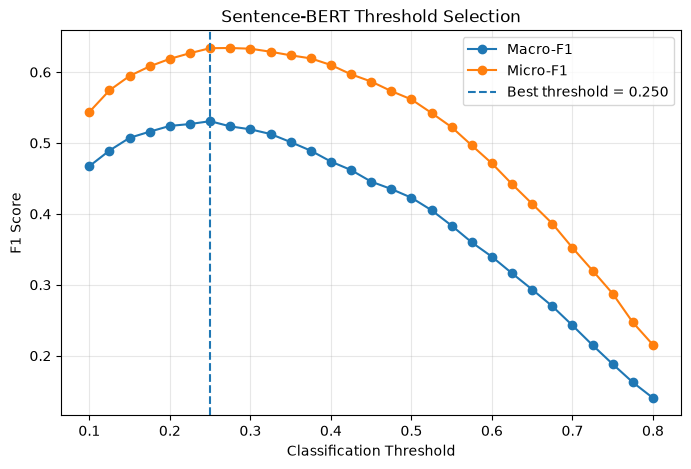

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    threshold_results["threshold"],
    threshold_results["macro_f1"],
    marker="o",
    label="Macro-F1"
)

plt.plot(
    threshold_results["threshold"],
    threshold_results["micro_f1"],
    marker="o",
    label="Micro-F1"
)

plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"Best threshold = {best_threshold:.3f}"
)

plt.xlabel("Classification Threshold")
plt.ylabel("F1 Score")
plt.title("Sentence-BERT Threshold Selection")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [35]:
pred_default = (val_scores >= 0.5).astype(int)
pred_best = (val_scores >= best_threshold).astype(int)

macro_default = f1_score(
    y_val,
    pred_default,
    average="macro",
    zero_division=0
)

macro_best = f1_score(
    y_val,
    pred_best,
    average="macro",
    zero_division=0
)

print(f"Default threshold 0.5 Macro-F1 : {macro_default:.4f}")
print(f"Best threshold {best_threshold:.3f} Macro-F1 : {macro_best:.4f}")
print(f"Absolute improvement            : {macro_best - macro_default:.4f}")

Default threshold 0.5 Macro-F1 : 0.4228
Best threshold 0.250 Macro-F1 : 0.5307
Absolute improvement            : 0.1079


In [36]:
true_labels_per_movie = y_val.sum(axis=1)

print(
    "Average true genres per movie:",
    true_labels_per_movie.mean()
)

Average true genres per movie: 2.67625


In [37]:
default_labels_per_movie = pred_default.sum(axis=1)
best_labels_per_movie = pred_best.sum(axis=1)

print(
    "Average predicted genres @ 0.5:",
    default_labels_per_movie.mean()
)

print(
    f"Average predicted genres @ {best_threshold:.3f}:",
    best_labels_per_movie.mean()
)

Average predicted genres @ 0.5: 1.74125
Average predicted genres @ 0.250: 3.61625


In [38]:
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(
    y_val,
    pred_best,
    average=None,
    zero_division=0
)

per_genre_results = pd.DataFrame({
    "genre_id": GENRE_IDS,
    "genre": GENRE_NAMES,
    "precision": precision,
    "recall": recall,
    "f1": f1,
    "support": support
})

display(
    per_genre_results.sort_values(
        "f1",
        ascending=False
    )
)

,genre_id,genre,precision,recall,f1,support
6,18,Drama,0.565581,0.940278,0.706312,720
0,28,Action,0.571942,0.854839,0.685345,372
3,35,Comedy,0.541622,0.862306,0.665339,581
14,878,Science Fiction,0.633484,0.700000,0.665083,200
7,10751,Family,0.626794,0.664975,0.645320,197
16,53,Thriller,0.533026,0.806977,0.641998,430
10,27,Horror,0.547368,0.728972,0.625251,214
1,12,Adventure,0.570248,0.674267,0.617910,307
17,10752,War,0.587302,0.606557,0.596774,61
4,80,Crime,0.551839,0.647059,0.595668,255


In [39]:
print("BEST GENRES")

display(
    per_genre_results
    .sort_values("f1", ascending=False)
    .head(5)
)

print("WORST GENRES")

display(
    per_genre_results
    .sort_values("f1", ascending=True)
    .head(5)
)

BEST GENRES


,genre_id,genre,precision,recall,f1,support
6,18,Drama,0.565581,0.940278,0.706312,720
0,28,Action,0.571942,0.854839,0.685345,372
3,35,Comedy,0.541622,0.862306,0.665339,581
14,878,Science Fiction,0.633484,0.700000,0.665083,200
7,10751,Family,0.626794,0.664975,0.645320,197


WORST GENRES


,genre_id,genre,precision,recall,f1,support
15,10770,TV Movie,0.000000,0.000000,0.000000,17
5,99,Documentary,0.000000,0.000000,0.000000,0
12,9648,Mystery,0.479452,0.440252,0.459016,159
9,36,History,0.514706,0.426829,0.466667,82
8,14,Fantasy,0.500000,0.510000,0.504950,200


In [40]:
print(
    "Average true genres per movie:",
    y_val.sum(axis=1).mean()
)

print(
    "Average predicted genres @ 0.5:",
    pred_default.sum(axis=1).mean()
)

print(
    f"Average predicted genres @ {best_threshold:.2f}:",
    pred_best.sum(axis=1).mean()
)

Average true genres per movie: 2.67625
Average predicted genres @ 0.5: 1.74125
Average predicted genres @ 0.25: 3.61625


In [41]:
prediction_count_stats = pd.DataFrame({
    "true_count": y_val.sum(axis=1),
    "pred_count_05": pred_default.sum(axis=1),
    "pred_count_best": pred_best.sum(axis=1)
})

display(prediction_count_stats.describe())

,true_count,pred_count_05,pred_count_best
count,1600.000000,1600.000000,1600.000000
mean,2.676250,1.741250,3.616250
std,1.095302,1.042222,1.217544
min,1.000000,0.000000,1.000000
25%,2.000000,1.000000,3.000000
50%,3.000000,2.000000,3.000000
75%,3.000000,2.000000,4.000000
max,8.000000,6.000000,8.000000


In [42]:
id_to_name = dict(
    zip(genres["id"], genres["name"])
)

def vector_to_genres(vector):
    return [
        id_to_name[genre_id]
        for genre_id, value
        in zip(GENRE_IDS, vector)
        if value == 1
    ]

In [43]:
i = 0
original_index = val_idx[i]

print("TITLE:")
print(train.iloc[original_index]["title"])

print("\nOVERVIEW:")
print(train.iloc[original_index]["overview"])

print("\nTRUE:")
print(vector_to_genres(y_val[i]))

print("\nPREDICTED:")
print(vector_to_genres(pred_best[i]))

TITLE:
An Italian Name

OVERVIEW:
Paolo is an outgoing and handsome real estate broker married to Simona, a beautiful woman from the rough outskirts of Rome who has become an author of spicy bestsellers and is pregnant with their child. Betta, Paolo’s sister and her husband Sandro organise a dinner party with Paolo, Simona and their childhood friend, the eccentric musician Claudio. During the lively gathering Paolo reveals what he would like to name his son, causing reactions to steam up and a torrent of revelations to follow reaching climactic proportions.

TRUE:
['Comedy']

PREDICTED:
['Comedy', 'Drama', 'Romance']


In [44]:
scores_df = pd.DataFrame({
    "genre": GENRE_NAMES,
    "score": val_scores[i]
}).sort_values(
    "score",
    ascending=False
)

display(scores_df)

,genre,score
3,Comedy,0.748122
6,Drama,0.744526
13,Romance,0.650919
4,Crime,0.143156
16,Thriller,0.102507
11,Music,0.038459
12,Mystery,0.032782
7,Family,0.018276
1,Adventure,0.013682
2,Animation,0.012908


In [45]:
exact_match = np.all(
    pred_best == y_val,
    axis=1
)

exact_indices = np.where(exact_match)[0]

print(
    "Exact-match movies:",
    len(exact_indices),
    "/",
    len(y_val)
)

Exact-match movies: 120 / 1600


In [46]:
for i in exact_indices[:5]:
    original_index = val_idx[i]

    print("=" * 80)
    print(train.iloc[original_index]["title"])
    print(train.iloc[original_index]["overview"][:500])

    print(
        "TRUE:",
        vector_to_genres(y_val[i])
    )

    print(
        "PRED:",
        vector_to_genres(pred_best[i])
    )

Next Goal Wins
Dutch coach Thomas Rongen attempts the nearly impossible task of turning the American Samoa soccer team from perennial losers into winners.
TRUE: ['Comedy', 'Drama']
PRED: ['Comedy', 'Drama']
Charlie Bartlett
Awkward teenager Charlie Bartlett has trouble fitting in at a new high school. Charlie needs some friends fast, and decides that the best way to find them is to appoint himself the resident psychiatrist. He becomes one of the most popular guys in school by doling out advice and, occasionally, medication, to the student body.
TRUE: ['Comedy', 'Drama', 'Romance']
PRED: ['Comedy', 'Drama', 'Romance']
Labyrinth
When Sarah is forced to babysit her half-brother Toby, she inadvertently summons the Goblin King who whisks Toby away to his castle at the center of a labyrinth. Sarah enters into a bargain with the Goblin King where she is given just thirteen hours to solve the labyrinth and rescue Toby, or else lose him forever.
TRUE: ['Adventure', 'Family', 'Fantasy']
PRED: ['

In [47]:
from sklearn.metrics import f1_score

sample_f1 = []

for i in range(len(y_val)):
    score = f1_score(
        y_val[i],
        pred_best[i],
        zero_division=0
    )
    sample_f1.append(score)

sample_f1 = np.array(sample_f1)

In [48]:
worst_indices = np.argsort(sample_f1)[:10]

for i in worst_indices:
    original_index = val_idx[i]

    print("=" * 80)
    print("TITLE:", train.iloc[original_index]["title"])

    print(
        "TRUE:",
        vector_to_genres(y_val[i])
    )

    print(
        "PRED:",
        vector_to_genres(pred_best[i])
    )

    print(
        "Sample F1:",
        sample_f1[i]
    )

    print(
        "OVERVIEW:",
        train.iloc[original_index]["overview"][:500]
    )

TITLE: Pet Sematary: Bloodlines
TRUE: ['Horror']
PRED: ['Adventure', 'Drama', 'Fantasy']
Sample F1: 0.0
OVERVIEW: In 1969, young Jud Crandall has dreams of leaving his hometown behind, but soon discovers sinister secrets buried within and is forced to confront a dark family history that forever binds him to Ludlow.
TITLE: We're No Angels
TRUE: ['Comedy', 'Crime']
PRED: ['Action', 'Drama', 'Thriller']
Sample F1: 0.0
OVERVIEW: Two escaped cons' only prayer to escape is to pass themselves off as priests and pass by the police blockade at the border into the safety of Canada.
TITLE: Brahms: The Boy II
TRUE: ['Horror', 'Mystery', 'Thriller']
PRED: ['Comedy', 'Drama', 'Family']
Sample F1: 0.0
OVERVIEW: After a family moves into the Heelshire Mansion, their young son soon makes friends with a life-like doll called Brahms.
TITLE: History of the World: Part I
TRUE: ['Comedy']
PRED: ['Drama', 'History']
Sample F1: 0.0
OVERVIEW: An uproarious version of history that proves nothing is sacred – not

In [49]:
val_movie_ids = (
    train.iloc[val_idx]["movie_id"]
    .to_numpy()
)

n_movies = len(val_idx)
n_genres = len(GENRE_IDS)

prediction_df = pd.DataFrame({
    "movie_id": np.repeat(
        val_movie_ids,
        n_genres
    ),

    "model": "sbert_lr",

    "variant": "original",

    "seed": SEED,

    "genre_id": np.tile(
        GENRE_IDS,
        n_movies
    ),

    "y_true": y_val.reshape(-1),

    "y_score": val_scores.reshape(-1),

    "y_pred": pred_best.reshape(-1)
})

display(prediction_df.head(30))

,movie_id,model,variant,seed,genre_id,y_true,y_score,y_pred
0,6818,sbert_lr,original,42,28,0,0.011956,0
1,6818,sbert_lr,original,42,12,0,0.013682,0
2,6818,sbert_lr,original,42,16,0,0.012908,0
3,6818,sbert_lr,original,42,35,1,0.748122,1
4,6818,sbert_lr,original,42,80,0,0.143156,0
5,6818,sbert_lr,original,42,99,0,0.000000,0
6,6818,sbert_lr,original,42,18,0,0.744526,1
7,6818,sbert_lr,original,42,10751,0,0.018276,0
8,6818,sbert_lr,original,42,14,0,0.010854,0
9,6818,sbert_lr,original,42,36,0,0.009855,0


In [50]:
print(prediction_df.shape)

(30400, 8)


In [51]:
print(prediction_df.columns.tolist())

print("\nModel:")
print(prediction_df["model"].unique())

print("\nVariant:")
print(prediction_df["variant"].unique())

print("\nSeed:")
print(prediction_df["seed"].unique())

print("\nGenres:")
print(prediction_df["genre_id"].nunique())

['movie_id', 'model', 'variant', 'seed', 'genre_id', 'y_true', 'y_score', 'y_pred']

Model:
<StringArray>
['sbert_lr']
Length: 1, dtype: str

Variant:
<StringArray>
['original']
Length: 1, dtype: str

Seed:
[42]

Genres:
19


In [52]:
movie_id = val_movie_ids[0]

display(
    prediction_df[
        prediction_df["movie_id"] == movie_id
    ]
)

,movie_id,model,variant,seed,genre_id,y_true,y_score,y_pred
0,6818,sbert_lr,original,42,28,0,0.011956,0
1,6818,sbert_lr,original,42,12,0,0.013682,0
2,6818,sbert_lr,original,42,16,0,0.012908,0
3,6818,sbert_lr,original,42,35,1,0.748122,1
4,6818,sbert_lr,original,42,80,0,0.143156,0
5,6818,sbert_lr,original,42,99,0,0.000000,0
6,6818,sbert_lr,original,42,18,0,0.744526,1
7,6818,sbert_lr,original,42,10751,0,0.018276,0
8,6818,sbert_lr,original,42,14,0,0.010854,0
9,6818,sbert_lr,original,42,36,0,0.009855,0


In [53]:
OUTPUT_DIR = Path("../predictions")
OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

output_path = (
    OUTPUT_DIR /
    "sbert_original_sanity.csv"
)

prediction_df.to_csv(
    output_path,
    index=False
)

print(output_path)

../predictions/sbert_original_sanity.csv


In [54]:
experiment_config = {
    "model": "sentence-transformers/all-MiniLM-L6-v2",
    "embedding_dimension": 384,
    "classifier": "OneVsRest LogisticRegression",
    "max_iter": 2000,
    "seed": SEED,
    "threshold": best_threshold,
    "split": "temporary random 80/20 sanity-check",
    "validation_macro_f1": float(
        best_row["macro_f1"]
    ),
    "validation_micro_f1": float(
        best_row["micro_f1"]
    ),
    "average_true_labels": float(
        y_val.sum(axis=1).mean()
    ),
    "average_predicted_labels": float(
        pred_best.sum(axis=1).mean()
    )
}

experiment_config

{'model': 'sentence-transformers/all-MiniLM-L6-v2',
 'embedding_dimension': 384,
 'classifier': 'OneVsRest LogisticRegression',
 'max_iter': 2000,
 'seed': 42,
 'threshold': 0.24999999999999997,
 'split': 'temporary random 80/20 sanity-check',
 'validation_macro_f1': 0.5307309652593897,
 'validation_micro_f1': 0.6336909018673024,
 'average_true_labels': 2.67625,
 'average_predicted_labels': 3.61625}